# Understanding Computer Vision

**Gudsky Research Foundation | Research Intake 2026 | Day 26**
*Module: Computer Vision Fundamentals*

This notebook is the end-to-end, executable companion to the Day 26 outline. Every section below runs real code (mostly on synthetically generated images so it works offline, with notes on how to swap in your own images) alongside the conceptual explanation, so you build intuition and muscle memory together.

**Requirements:** `numpy`, `matplotlib`, `pillow`, `opencv-python`, `torch`, `torchvision`, `scikit-learn`. Run the setup cell below first.

---

## Table of Contents
1. [Introduction to Computer Vision](#1)
2. [Digital Image Representation & Color Spaces](#2)
3. [Human Vision vs. Computer Vision](#3)
4. [The Computer Vision Task Taxonomy](#4)
5. [The Classical CV Pipeline (Pre-Deep-Learning Era)](#5)
6. [The Deep Learning Shift in Computer Vision](#6)
7. [Core CV Libraries & Tooling](#7)
8. [Evaluation Metrics in Computer Vision](#8)
9. [Real-World Applications & Ethical Considerations](#9)
10. [Research Frontiers](#10)
11. [Assignment: PP12 — Face Mask Detection](#11)


In [2]:
# Setup
import sys, subprocess

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg, name in [("numpy", "numpy"), ("matplotlib", "matplotlib"), ("pillow", "PIL"),
                   ("opencv-python-headless", "cv2"), ("torch", "torch"),
                   ("torchvision", "torchvision"), ("scikit-learn", "sklearn")]:
    ensure(pkg, name)

import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

np.random.seed(26)
print("Environment ready.")


Environment ready.


<a id='1'></a>
## 1. Introduction to Computer Vision

**What it is.** Computer Vision (CV) is the field of teaching machines to extract meaning from visual data — images, video, depth maps, LIDAR point clouds — the way biological vision extracts meaning from light. It sits at the intersection of image processing, statistics, and (today) deep learning.

**A short history.**
- **1966 — "The Summer Vision Project."** MIT researchers famously assigned solving computer vision as a summer project. It took closer to 50+ years and counting — a good early lesson in why vision is deceptively hard.
- **1970s–2000s — the classical era.** Handcrafted features and geometric/statistical methods: edge detectors, corner detectors, SIFT/HOG descriptors, Viola-Jones face detection.
- **2012 — the ImageNet moment.** AlexNet, a deep convolutional neural network, beat the previous best ImageNet classification error by a huge margin, ushering in the deep learning era for vision.
- **2015–2020 — architecture explosion.** ResNet, YOLO, Mask R-CNN, and friends push classification, detection, and segmentation to near/above human performance on benchmark tasks.
- **2020s — foundation models.** CLIP, SAM, DINO, and vision-language models bring large-scale self-supervised pretraining and unified/promptable vision systems, blurring the old task boundaries.

**Why vision is hard: the inverse optics problem.** A camera performs a many-to-one projection: infinite 3D scenes can produce the same 2D pixel grid (same image, different lighting/object/pose combos can look identical). Vision is therefore an *ill-posed inverse problem* — recovering 3D structure, material, and semantics from a 2D projection requires strong priors, which is exactly what learning-based methods are good at acquiring from data.

> **Callout — Why Vision Is Hard:** Reconstructing the world from pixels is like trying to recover a person's exact height, weight, and distance from a single silhouette photo — many different combinations produce the identical silhouette. Vision systems resolve this ambiguity using learned priors about how the world usually looks.

### The 12-Day Arc (where this module is headed)

| Days | Theme |
|---|---|
| **26–28** | Foundations & classical methods (this notebook, then preprocessing/augmentation, then handcrafted features SIFT/HOG) |
| **29–30** | The deep learning shift — CNN architectures |
| **31–33** | Applying learned features — detection, tracking, segmentation |
| **34–35** | Generative modeling — GANs and diffusion |
| **36** | 3D / video understanding |
| **37** | Explainability + medical imaging (highest-stakes application domain) |

Keep this roadmap in mind — later sections in this notebook explicitly flag where a topic is picked up in more depth on a later day.


<a id='2'></a>
## 2. Digital Image Representation & Color Spaces

A digital image is a **tensor** of shape `(H, W, C)`: height × width × channels. Each entry is a pixel intensity, typically an 8-bit unsigned integer (`0-255`) per channel — this is the **bit depth**. Higher bit depths (e.g., 16-bit) are used in medical/scientific imaging for finer intensity resolution.

- **Grayscale**: `(H, W)` — one channel, intensity only.
- **RGB**: `(H, W, 3)` — Red, Green, Blue. The standard for display and most deep learning pipelines.
- **BGR**: same as RGB but channel-reversed. **OpenCV's default and the #1 beginner gotcha** — `cv2.imread` loads BGR, but `matplotlib`/PIL expect RGB, so images look blue-tinted unless you convert.
- **HSV** (Hue, Saturation, Value): separates color identity from intensity — very useful for color-based segmentation ("find all red pixels") since it's more robust to lighting changes than RGB.
- **YCbCr**: separates luma (brightness) from chroma (color) — used heavily in JPEG compression, since the human eye is more sensitive to brightness than color detail.

**File formats.** JPEG uses lossy compression (discrete cosine transform + quantization) — great for photos, small files, but introduces blocky "JPEG artifacts" under heavy compression or repeated re-saving. PNG is lossless — better for screenshots, diagrams, or anything requiring pixel-perfect fidelity (e.g., segmentation masks), at the cost of larger files.

Let's make this concrete with code.


Image tensor shape (H, W, C): (200, 300, 3)
dtype: uint8 | min/max pixel value: 60 255


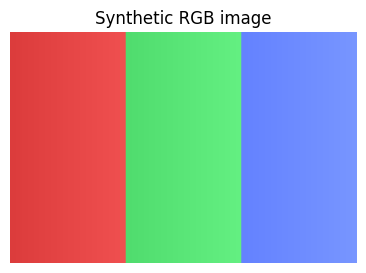

In [3]:
# Build a synthetic RGB image so this runs without external downloads.
# (Swap in your own file with: img_rgb = np.array(Image.open('your_image.jpg').convert('RGB')) )

H, W = 200, 300
img_rgb = np.zeros((H, W, 3), dtype=np.uint8)
img_rgb[:, :100] = [220, 60, 60]     # red patch
img_rgb[:, 100:200] = [60, 200, 90]  # green patch
img_rgb[:, 200:] = [60, 90, 220]     # blue patch
# add a soft gradient so it's not perfectly flat
gradient = np.linspace(0, 60, W).astype(np.uint8)
img_rgb = np.clip(img_rgb.astype(int) + gradient[None, :, None], 0, 255).astype(np.uint8)

print("Image tensor shape (H, W, C):", img_rgb.shape)
print("dtype:", img_rgb.dtype, "| min/max pixel value:", img_rgb.min(), img_rgb.max())
plt.figure(figsize=(5, 3))
plt.imshow(img_rgb)
plt.title("Synthetic RGB image")
plt.axis('off')
plt.show()


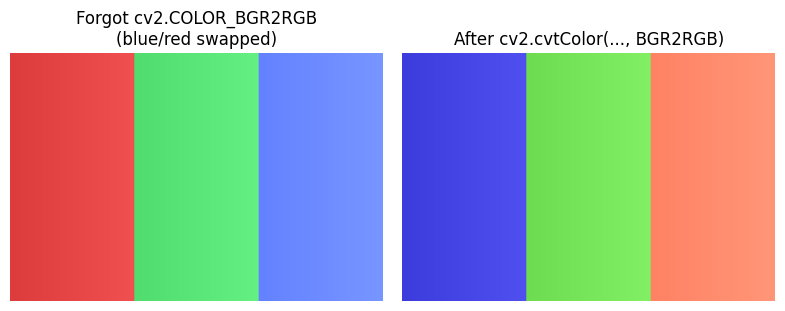

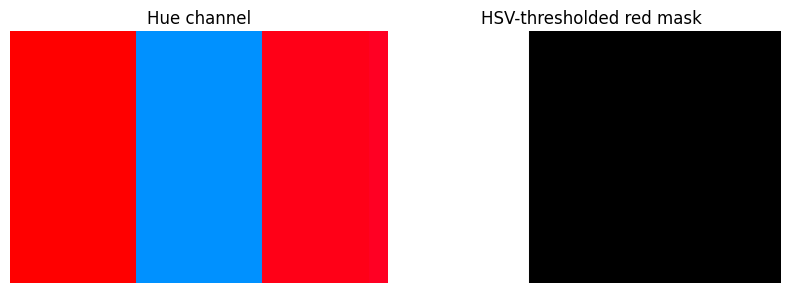

In [4]:
# 2.1 Color Spaces in Practice — the BGR/RGB gotcha and HSV segmentation

# Simulate the OpenCV gotcha: OpenCV treats arrays as BGR by default.
img_bgr_misread = img_rgb  # pretend this came from cv2.imread (already BGR-ordered in memory)
wrongly_shown_as_rgb = img_bgr_misread  # if you forget to convert, colors swap
correctly_converted = cv2.cvtColor(img_bgr_misread, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(wrongly_shown_as_rgb); axes[0].set_title("Forgot cv2.COLOR_BGR2RGB\n(blue/red swapped)"); axes[0].axis('off')
axes[1].imshow(correctly_converted); axes[1].set_title("After cv2.cvtColor(..., BGR2RGB)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

# HSV for color-based segmentation: isolate the "red" patch regardless of lighting gradient
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
lower_red = np.array([0, 80, 80])
upper_red = np.array([15, 255, 255])
red_mask = cv2.inRange(img_hsv, lower_red, upper_red)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(img_hsv[..., 0], cmap='hsv'); axes[0].set_title("Hue channel"); axes[0].axis('off')
axes[1].imshow(red_mask, cmap='gray'); axes[1].set_title("HSV-thresholded red mask"); axes[1].axis('off')
plt.tight_layout(); plt.show()


<a id='3'></a>
## 3. Human Vision vs. Computer Vision

**Biological inspiration.** Light hits the retina, is pre-processed by retinal ganglion cells, then travels via the optic nerve to the primary visual cortex (**V1**), which detects simple features like oriented edges — remarkably similar to what the first layer of a trained CNN learns. Signal then flows through higher visual areas (V2, V4, IT cortex) that build up increasingly abstract representations — edges → textures → parts → objects. This hierarchy loosely inspired the layered structure of CNNs (simple filters in early layers, complex/semantic filters in deep layers).

**Where the analogy breaks down.**
- Human vision has *active* control (eye saccades, attention) and constant top-down feedback from context and memory; most feedforward CNNs do not.
- Human vision is remarkably **robust to distribution shift** (fog, unusual angles, occlusion) in ways that trained CNNs often are not.
- **Adversarial examples** are the sharpest evidence of the gap: imperceptibly perturbing a handful of pixels (invisible to a human) can flip a CNN's prediction with high confidence — a model that "sees" a stop sign as a speed limit sign because of an almost-invisible pixel pattern. This shows CNNs learn statistical regularities that don't always align with human-relevant semantics.
- **Marr's computational theory of vision** (David Marr, 1980s) proposed vision happens across three levels: the *computational* level (what problem is being solved and why), the *algorithmic* level (what representations and procedures are used), and the *implementational* level (how it's physically realized — neurons, or silicon). It's a useful lens for CV engineering too: always ask what problem you're really solving before picking an architecture.


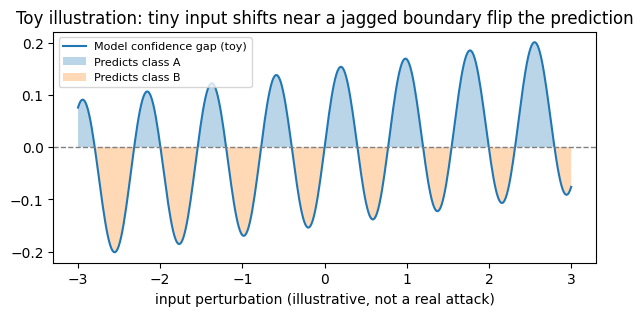

In [5]:
# A tiny, safe illustration of "small input changes can cause large output changes" —
# a caricature of the adversarial-example idea using a toy classifier (no real attack, just intuition).

rng = np.random.default_rng(26)
x = np.linspace(-3, 3, 400)
# A deliberately jagged decision function to represent a model with sharp, non-robust decision boundaries
decision_score = np.sin(8 * x) * 0.15 + 0.02 * x

plt.figure(figsize=(7, 3))
plt.plot(x, decision_score, label="Model confidence gap (toy)")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.fill_between(x, decision_score, 0, where=(decision_score > 0), alpha=0.3, label="Predicts class A")
plt.fill_between(x, decision_score, 0, where=(decision_score <= 0), alpha=0.3, label="Predicts class B")
plt.title("Toy illustration: tiny input shifts near a jagged boundary flip the prediction")
plt.xlabel("input perturbation (illustrative, not a real attack)")
plt.legend(loc='upper left', fontsize=8)
plt.show()


<a id='4'></a>
## 4. The Computer Vision Task Taxonomy

This taxonomy underpins Days 29–35, so it's worth internalizing precisely — each task answers a different question about an image.

| Task | Question answered | Output | Later day |
|---|---|---|---|
| **Image classification** | "What is the main subject?" | One label per image | Day 29–30 |
| **Object localization** | "Where is the (single) subject?" | One bounding box + label | Day 31 |
| **Object detection** | "What objects, and where, all of them?" | Multiple bounding boxes + labels | Day 31 |
| **Semantic segmentation** | "Which pixels belong to which class?" | Per-pixel class map (instances of same class merged) | Day 33 |
| **Instance segmentation** | "Which pixels belong to which *individual* object?" | Per-pixel mask per object instance | Day 33 |
| **Panoptic segmentation** | Semantic + instance, unified | Every pixel labeled with class *and* instance ID | Day 33 |
| **Keypoint / pose estimation** | "Where are specific anatomical/structural points?" | Set of (x, y) keypoints (e.g., joints) | Day 32 |
| **Image generation** | "Produce a plausible new image" | A synthesized image | Day 34–35 |

> **Research Spotlight:** Foundation models like **SAM** (Segment Anything Model) have blurred this taxonomy — a single promptable model can perform detection-like, segmentation-like, and even tracking-like behavior depending on the prompt (a point, a box, a text query), rather than requiring a separately trained head per task. The taxonomy above is still the right mental model for *what* is being asked of a system, even as the *how* increasingly converges into unified architectures.


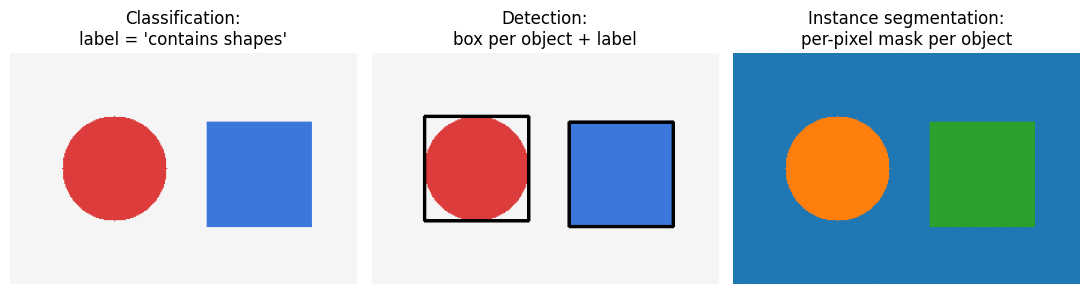

In [6]:
# Visualize the taxonomy differences on one synthetic scene: classification vs detection vs segmentation

scene = np.ones((200, 300, 3), dtype=np.uint8) * 245
cv2.circle(scene, (90, 100), 45, (220, 60, 60), -1)     # "object" 1 (circle)
cv2.rectangle(scene, (170, 60), (260, 150), (60, 120, 220), -1)  # "object" 2 (square)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

axes[0].imshow(scene); axes[0].set_title("Classification:\nlabel = 'contains shapes'"); axes[0].axis('off')

det = scene.copy()
cv2.rectangle(det, (45, 55), (135, 145), (0, 0, 0), 2)
cv2.rectangle(det, (170, 60), (260, 150), (0, 0, 0), 2)
axes[1].imshow(det); axes[1].set_title("Detection:\nbox per object + label"); axes[1].axis('off')

seg = np.zeros((200, 300), dtype=np.uint8)
cv2.circle(seg, (90, 100), 45, 1, -1)
cv2.rectangle(seg, (170, 60), (260, 150), 2, -1)
axes[2].imshow(seg, cmap='tab10', vmin=0, vmax=9)
axes[2].set_title("Instance segmentation:\nper-pixel mask per object"); axes[2].axis('off')

plt.tight_layout(); plt.show()


<a id='5'></a>
## 5. The Classical CV Pipeline (Pre-Deep-Learning Era)

Before deep learning, CV pipelines were built from **handcrafted, mathematically-defined operators** chained together — a designer decided *which* features mattered, rather than learning them from data.

- **Edge detection.** Edges are where intensity changes sharply. **Sobel** computes an approximate image gradient via convolution with small directional kernels (fast, noisy). **Canny** is a multi-stage refinement — smoothing, gradient computation, non-maximum suppression, and hysteresis thresholding — producing thin, clean edge maps.
- **Corner detection** (e.g., Harris corners) finds points where intensity changes sharply in *multiple* directions — good stable "anchor points" for matching between images.
- **Handcrafted feature descriptors — SIFT and HOG** (the direct bridge into Day 28): SIFT (Scale-Invariant Feature Transform) finds keypoints stable across scale/rotation/illumination and describes local gradient patterns around them, historically used for matching and stitching. HOG (Histogram of Oriented Gradients) summarizes local edge-orientation statistics over a grid of cells — the feature representation famously paired with an SVM for pedestrian detection.
- **Template matching** slides a reference patch over an image and scores similarity at each location — simple but brittle to scale/rotation/lighting changes.
- **Why these plateaued.** Handcrafted features encode a designer's assumptions about what matters, so they generalize poorly to unseen variation (lighting, occlusion, pose, background clutter) that wasn't anticipated at design time. Deep networks instead *learn* which features matter directly from data, which is why they overtook classical pipelines once enough labeled data and compute became available (Section 6).
- **Viola-Jones face detection** (2001) is the classical era's most influential success story: a cascade of simple Haar-like features + AdaBoost, fast enough for real-time detection on 2001-era hardware. It's the direct historical ancestor of **PP12's Approach B** below — a fast face localizer feeding a downstream classifier.


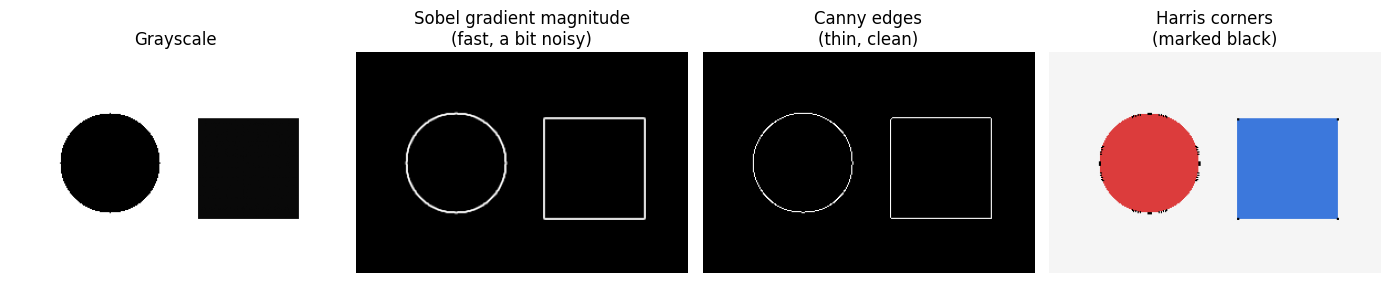

Sobel and Canny both find 'where intensity changes' but Canny's multi-stage refinement gives cleaner, thinner edges.


In [7]:
# Classical pipeline on our synthetic scene: grayscale -> Sobel vs Canny edges -> Harris corners

gray = cv2.cvtColor(scene, cv2.COLOR_RGB2GRAY)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = (255 * sobel_mag / (sobel_mag.max() + 1e-6)).astype(np.uint8)

canny_edges = cv2.Canny(gray, threshold1=50, threshold2=150)

corners = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=0.04)
corner_vis = scene.copy()
corner_vis[corners > 0.01 * corners.max()] = [0, 0, 0]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
axes[0].imshow(gray, cmap='gray'); axes[0].set_title("Grayscale"); axes[0].axis('off')
axes[1].imshow(sobel_mag, cmap='gray'); axes[1].set_title("Sobel gradient magnitude\n(fast, a bit noisy)"); axes[1].axis('off')
axes[2].imshow(canny_edges, cmap='gray'); axes[2].set_title("Canny edges\n(thin, clean)"); axes[2].axis('off')
axes[3].imshow(corner_vis); axes[3].set_title("Harris corners\n(marked black)"); axes[3].axis('off')
plt.tight_layout(); plt.show()

print("Sobel and Canny both find 'where intensity changes' but Canny's multi-stage refinement gives cleaner, thinner edges.")


<a id='6'></a>
## 6. The Deep Learning Shift in Computer Vision

**The 2012 moment.** AlexNet (Krizhevsky, Sutskever, Hinton) won the ImageNet Large Scale Visual Recognition Challenge by a huge margin using a deep CNN trained on GPUs — proof that *learned* features could dramatically outperform *handcrafted* ones (Section 5) given enough data and compute.

**Why convolutions suit images.**
- **Local receptive fields**: each neuron looks at a small local patch, matching the fact that nearby pixels are statistically related (an edge is a local phenomenon).
- **Weight sharing**: the same small filter (e.g., 3×3) slides across the whole image, drastically cutting parameters vs. a fully-connected layer and letting the network detect a pattern anywhere in the image, not just where it happened to appear during training.
- **Translation invariance** (approximately): because of weight sharing + pooling, a cat detected in the top-left of an image activates the same filter as a cat in the bottom-right.

**Transfer learning & pretrained backbones.** Training a large CNN from scratch needs huge labeled datasets. In practice, we take a backbone pretrained on a large generic dataset (e.g., ImageNet) — which has already learned generic low/mid-level visual features (edges → textures → parts) — and **fine-tune** just the last layer(s) on our smaller, task-specific dataset. This is the single most important practical technique in applied CV and is exactly the strategy PP12's Approach A uses below.

*(Full CNN architecture depth — convolution/pooling math, ResNet skip connections, etc. — is Day 29's focus; this section only motivates why the shift happened.)*


In [8]:
# Minimal from-scratch CNN block to make "local receptive field + weight sharing" concrete,
# then a transfer-learning skeleton using a pretrained torchvision backbone.

import torch
import torch.nn as nn

class TinyConvBlock(nn.Module):
    """One learnable 3x3 filter applied with weight sharing across the whole image."""
    def __init__(self, in_ch=3, out_ch=8):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        return self.pool(self.relu(self.conv(x)))

block = TinyConvBlock()
dummy_batch = torch.randn(1, 3, 64, 64)  # (batch, channels, H, W)
out = block(dummy_batch)
n_params = sum(p.numel() for p in block.parameters())
print("Input shape :", tuple(dummy_batch.shape))
print("Output shape:", tuple(out.shape), " (halved spatially by the pool, 8 learned feature maps)")
print("Learnable parameters in this block:", n_params,
      "\n-> Compare to a fully-connected layer over a 64x64x3 image, which would need millions.")


Input shape : (1, 3, 64, 64)
Output shape: (1, 8, 32, 32)  (halved spatially by the pool, 8 learned feature maps)
Learnable parameters in this block: 224 
-> Compare to a fully-connected layer over a 64x64x3 image, which would need millions.


In [9]:
# Transfer learning skeleton: pretrained backbone + new head (weights not downloaded here to keep this offline-safe;
# in practice set weights=<Weights>.DEFAULT to fetch ImageNet-pretrained weights).
import torchvision.models as models

backbone = models.mobilenet_v2(weights=None)  # set weights=models.MobileNet_V2_Weights.DEFAULT for real pretraining
num_classes = 3  # e.g., PP12: mask / no-mask / incorrect-mask

# Freeze the pretrained feature extractor...
for param in backbone.features.parameters():
    param.requires_grad = False

# ...and replace only the classification head, which we DO train.
backbone.classifier[-1] = nn.Linear(backbone.classifier[-1].in_features, num_classes)

trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total = sum(p.numel() for p in backbone.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} total")
print("This is the transfer-learning pattern used directly in PP12 Approach A below.")


Trainable parameters: 3,843 / 2,227,715 total
This is the transfer-learning pattern used directly in PP12 Approach A below.


<a id='7'></a>
## 7. Core CV Libraries & Tooling

| Library | Best for | Notes |
|---|---|---|
| **OpenCV** (`cv2`) | Classical ops, video I/O, real-time pipelines | C++ core with Python bindings → fast; BGR by default (Section 2 gotcha) |
| **PIL / Pillow** | Basic manipulation — resize, crop, format conversion, simple filters | Simple, Pythonic API; RGB by default; less suited to heavy numerical ops |
| **torchvision / timm** | Pretrained model zoos, standard transforms | `torchvision` ships with torch; `timm` has a much larger zoo of SOTA backbones |
| **albumentations** | Fast, rich data augmentation pipelines | Composable transforms, GPU-friendly, integrates with detection/segmentation labels (not just images) |

This section only *introduces* these tools — **Day 27 revisits this exact same toolset** to cover the specific preprocessing and augmentation operations (resizing strategies, normalization, augmentation policies for training robustness) that they're used for in practice, so keep this table as a reference point rather than the full story.


In [10]:
# A quick side-by-side: the same resize operation in PIL vs OpenCV vs torchvision transforms

from PIL import Image as PILImage
import torchvision.transforms as T

pil_img = PILImage.fromarray(img_rgb)

# PIL
pil_resized = pil_img.resize((150, 100))

# OpenCV
cv_resized = cv2.resize(img_rgb, (150, 100), interpolation=cv2.INTER_LINEAR)

# torchvision transform (commonly composed into a training pipeline)
tv_transform = T.Compose([T.ToPILImage(), T.Resize((100, 150)), T.ToTensor()])
tv_resized_tensor = tv_transform(img_rgb)  # -> torch.Tensor, shape (C, H, W), values in [0,1]

print("PIL result type       :", type(pil_resized), pil_resized.size)
print("OpenCV result shape   :", cv_resized.shape, cv_resized.dtype)
print("torchvision tensor    :", tuple(tv_resized_tensor.shape), tv_resized_tensor.dtype,
      "min/max:", tv_resized_tensor.min().item(), tv_resized_tensor.max().item())
print("\nNote the three libraries disagree on: value range (0-255 vs 0-1), axis order (HWC vs CHW), and default resampling.")


PIL result type       : <class 'PIL.Image.Image'> (150, 100)
OpenCV result shape   : (100, 150, 3) uint8
torchvision tensor    : (3, 100, 150) torch.float32 min/max: 0.23529411852359772 1.0

Note the three libraries disagree on: value range (0-255 vs 0-1), axis order (HWC vs CHW), and default resampling.


<a id='8'></a>
## 8. Evaluation Metrics in Computer Vision

Different CV tasks need different metrics — this section stays concise since deep dives happen inside each later day's relevant section (mAP on Day 31, Dice/IoU on Day 33).

- **Classification**: **Accuracy** (fraction correct); **Top-k accuracy** (correct label is among the model's top *k* predictions) — standard for large-label-space benchmarks like ImageNet.
- **Detection**: **IoU** (Intersection over Union) measures bounding-box overlap quality; **Precision/Recall** trade off false positives vs. false negatives at a confidence threshold; **mAP** (mean Average Precision) aggregates precision-recall performance across classes and IoU thresholds into one number *(forward reference — full treatment on Day 31)*.
- **Segmentation**: **Pixel accuracy** (fraction of correctly classified pixels); **Dice coefficient** and **IoU** (same overlap idea as detection, but pixel-mask vs. pixel-mask) *(forward reference — full treatment on Day 33)*.


In [11]:
# IoU (used in both detection and segmentation) implemented from scratch

def iou_boxes(box_a, box_b):
    """box = (x1, y1, x2, y2)"""
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b
    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0.0

ground_truth_box = (45, 55, 135, 145)   # from Section 4's synthetic detection example
predicted_box    = (55, 60, 140, 150)   # a slightly-off prediction

score = iou_boxes(ground_truth_box, predicted_box)
print(f"IoU(ground_truth, prediction) = {score:.3f}")
print("Convention: IoU >= 0.5 is typically counted as a 'correct' detection (the PASCAL VOC standard).")

def dice_coefficient(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    return 2 * intersection / (mask_a.sum() + mask_b.sum() + 1e-8)

gt_mask = seg == 1     # circle mask from Section 4
pred_mask = np.roll(gt_mask, shift=5, axis=1)  # simulate a slightly shifted prediction
print(f"Dice(ground_truth_mask, predicted_mask) = {dice_coefficient(gt_mask, pred_mask):.3f}")
print(f"IoU (segmentation) of the same masks     = {np.logical_and(gt_mask, pred_mask).sum() / np.logical_or(gt_mask, pred_mask).sum():.3f}")


IoU(ground_truth, prediction) = 0.760
Convention: IoU >= 0.5 is typically counted as a 'correct' detection (the PASCAL VOC standard).
Dice(ground_truth_mask, predicted_mask) = 0.930
IoU (segmentation) of the same masks     = 0.869


<a id='9'></a>
## 9. Real-World Applications & Ethical Considerations

**Applications across domains.**
- **Healthcare** — tumor detection/segmentation in radiology, diabetic retinopathy screening, surgical guidance (previews Day 37).
- **Security** — facial recognition access control, anomaly/intrusion detection in surveillance feeds.
- **Retail** — shelf-stock monitoring, cashier-less checkout, visual search.
- **Autonomous vehicles** — lane detection, pedestrian/vehicle detection, depth estimation, sensor fusion.
- **Agriculture** — crop health monitoring from drone/satellite imagery, pest detection, yield estimation.

**Direct tie-in to PP12 (Face Mask Detection):** this is a **public-health screening** use case — automated compliance monitoring at entry points (hospitals, factories, transit hubs), where the system's role is advisory/monitoring rather than punitive, which matters for how false positives/negatives should be weighed (see the design-choice discussion in Section 11).

**Ethical considerations.**
- **Bias and accuracy disparities.** Facial analysis systems have documented, measured accuracy gaps across skin tone and gender — models trained on unrepresentative datasets perform worse on underrepresented groups. This is a *data and evaluation problem*, not an unfixable property of vision models, but it requires deliberately auditing performance per subgroup, not just in aggregate.
- **Surveillance concerns.** The same detection/recognition tools that enable public-health screening (PP12) can enable mass surveillance — the technology is dual-use, and deployment context determines the ethical weight.
- **Consent and privacy.** Capturing and processing images of people's faces raises consent questions distinct from, say, classifying photos of fruit — especially for biometric identification (vs. mere detection).
- **Dataset bias.** A model is only as representative as its training data; datasets skewed by geography, lighting conditions, camera types, or demographics propagate that skew into deployed behavior.

> **Callout — Bias in facial analysis systems:** Landmark audits of commercial facial analysis systems (e.g., Gender Shades, Buolamwini & Gebru, 2018) found substantially higher error rates for darker-skinned women than for lighter-skinned men across multiple commercial systems — a widely cited example of why per-subgroup evaluation is not optional in production face-related systems.


<a id='10'></a>
## 10. Research Frontiers

- **Foundation models**: **CLIP** (contrastive image-text pretraining, enabling zero-shot classification via natural-language class names), **DINO** (self-supervised representation learning that produces surprisingly strong features without any labels), **SAM** (Segment Anything Model, promptable segmentation of arbitrary objects, referenced in Section 4).
- **Vision Transformers (ViT)**: an alternative to CNNs that treats an image as a sequence of patches and applies the Transformer self-attention architecture directly — trades CNNs' built-in locality/translation-invariance biases for more flexible, data-hungry global attention *(sets up Day 30's CNN-vs-ViT comparison)*.
- **Multimodal vision-language models**: models that jointly reason over images and text — captioning, visual question answering, instruction-following multimodal assistants.
- **Self-supervised pretraining**: learning strong visual representations from unlabeled images (via pretext tasks like contrastive learning or masked-patch prediction), reducing dependence on expensive human-labeled datasets — the same underlying idea that made CLIP and DINO possible.


<a id='11'></a>
## Assignment / Practical Project Brief

### PP12: Face Mask Detection

This is framed as a **design-choice discussion**, not a single prescribed pipeline. Both approaches are legitimate; the right choice depends on your deployment scenario.

#### Approach A — Classification
Assumes a pre-cropped face is already given. Transfer learning on a pretrained CNN backbone (e.g., **MobileNetV2** or **ResNet**) with a `mask / no-mask / incorrect-mask` head — exactly the pattern built in Section 6's transfer-learning skeleton. Simpler and faster to train, but requires an upstream face detector in any real deployment (this system alone doesn't know *where* a face is).

#### Approach B — Detection
Locates face(s) in an **uncropped** image *and* classifies mask status per face in one pass — e.g., a lightweight SSD/YOLO-style detection head trained end-to-end, or a classical **Viola-Jones**/MTCNN face detector (Section 5) feeding the Approach-A classifier in series. More realistic for actual deployment (e.g., an entry-screening camera feed with multiple people, arbitrary framing), but more complex to train and evaluate — you now need bounding-box annotations, not just image-level labels, and you evaluate with **IoU/mAP** (Section 8), not just accuracy.

#### Comparison

| Dimension | Approach A (Classification) | Approach B (Detection) |
|---|---|---|
| Accuracy on cropped faces | High (simpler problem) | Comparable, if trained well |
| Inference speed | Fast (single small CNN forward pass) | Slower (localization + classification per frame) |
| Data/annotation requirements | Image-level labels only | Bounding-box + class annotations (more expensive) |
| Deployment realism | Needs an external face detector to be useful | Directly deployable on raw camera feeds |
| Evaluation metric | Accuracy / top-k accuracy | IoU, precision/recall, mAP |

#### Suggested datasets
- Face Mask Detection dataset (Kaggle) — labeled bounding boxes, suits Approach B directly.
- MaskedFace-Net / Real-World-Masked-Face-Dataset — larger-scale, more label noise, good for robustness testing.
- For Approach A: crop faces from any of the above using a face detector first (or use a pre-cropped mask-classification dataset if available).

#### Grading rubric (suggested)
1. **Correctness** — pipeline runs end-to-end, produces valid predictions on held-out data.
2. **Evaluation rigor** — correct metric for the chosen approach (accuracy vs. IoU/mAP), reported on a proper train/val/test split.
3. **Design justification** — a short written rationale for which approach was chosen and why, referencing the comparison table above.
4. **Error analysis** — at least a few concrete failure cases inspected (e.g., dark lighting, side profile, patterned masks) and a discussion of why they failed.
5. **(Bonus)** Attempt both approaches and directly compare their speed/accuracy trade-off on the same test set.

#### Tips & common pitfalls
- Remember the **BGR/RGB gotcha** (Section 2) if you load data with OpenCV but visualize with matplotlib.
- **Class imbalance**: "no-mask" and "incorrect-mask" are typically rarer than "mask" in most datasets — check your class distribution before training, and consider weighted loss or resampling.
- For Approach A, **freeze the backbone first**, train just the head, then optionally unfreeze the last few backbone layers for a low-learning-rate fine-tune — don't fine-tune the whole pretrained backbone from the start on a small dataset (risk of overfitting/catastrophic forgetting).
- For Approach B, IoU threshold choice (commonly 0.5) directly affects your reported mAP — always state it.
- Test on images with **multiple faces, varied lighting, and partial occlusion** — these are exactly the conditions a real entry-screening camera will see, and exactly where classical face detectors (Viola-Jones/MTCNN) can start to struggle compared to learned detectors.

#### Dataset — Kaggle: Face Mask Dataset (With and without mask)

This notebook uses **[belsonraja/face-mask-dataset-with-and-without-mask](https://www.kaggle.com/datasets/belsonraja/face-mask-dataset-with-and-without-mask)** for Approach A. It's a binary (`with_mask` / `without_mask`) image-folder dataset, which maps directly onto the transfer-learning classifier built in Section 6.

> **A note on running this on Kaggle vs. elsewhere:** `kagglehub` needs your Kaggle credentials, and the download itself needs network access to `kaggle.com` — neither is available inside the sandbox that generated this notebook, so the download cell below has **not** been executed here. It **will** run as-is in Google Colab, a local Jupyter install, or (with zero setup) directly inside a Kaggle Notebook. To authenticate outside Kaggle's own notebooks: Kaggle account -> Settings -> API -> Create New Token, which downloads `kaggle.json`; place it at `~/.kaggle/kaggle.json` (or set the `KAGGLE_USERNAME`/`KAGGLE_KEY` environment variables), then run the cell below.

If the class-folder names in the download differ slightly from `with_mask`/`without_mask` (Kaggle authors aren't always consistent), the loader below auto-detects class folders by scanning for the image-containing subdirectories with the most images, so it's robust to minor naming differences.


In [12]:
# Download the dataset (requires Kaggle credentials + network access -- see note above).
import os

DATA_ROOT = None
try:
    import kagglehub
    DATA_ROOT = kagglehub.dataset_download("belsonraja/face-mask-dataset-with-and-without-mask")
    print("Dataset downloaded to:", DATA_ROOT)
except Exception as e:
    print("Could not download via kagglehub in this environment "
          f"({type(e).__name__}: {e}).")
    print("Set DATA_ROOT manually to a local copy of the dataset to proceed, e.g.:")
    print("  DATA_ROOT = '/path/to/face-mask-dataset-with-and-without-mask'")


Using Colab cache for faster access to the 'face-mask-dataset-with-and-without-mask' dataset.
Dataset downloaded to: /kaggle/input/face-mask-dataset-with-and-without-mask


In [13]:
# Locate the class folders inside the downloaded dataset (robust to nested/renamed subfolders).
from pathlib import Path
from collections import Counter

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def find_class_dirs(root, min_images=20):
    """Scan for subdirectories that directly contain a meaningful number of images --
    treat each as a class. Handles a dataset root that nests one or two levels deep."""
    root = Path(root)
    counts = Counter()
    for p in root.rglob('*'):
        if p.suffix.lower() in IMG_EXTS:
            counts[p.parent] += 1
    return {d: n for d, n in counts.items() if n >= min_images}

if DATA_ROOT is not None:
    class_dirs = find_class_dirs(DATA_ROOT)
    for d, n in sorted(class_dirs.items(), key=lambda kv: -kv[1]):
        print(f"{n:5d} images  ->  {d}")
    if not class_dirs:
        print("No class folders auto-detected -- inspect the downloaded tree with `Path(DATA_ROOT).rglob('*')`.")
else:
    class_dirs = {}
    print("Skipping (no DATA_ROOT). Set DATA_ROOT above and re-run this cell once you have a local copy.")


 1918 images  ->  /kaggle/input/face-mask-dataset-with-and-without-mask/facemask-dataset/dataset/without_mask
 1915 images  ->  /kaggle/input/face-mask-dataset-with-and-without-mask/facemask-dataset/dataset/with_mask


In [14]:
# Build the PyTorch Dataset/DataLoaders from the detected class folders.
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

IMG_SIZE = 224

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet stats, matches the pretrained backbone
])
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FaceMaskFolderDataset(Dataset):
    """Wraps the auto-detected class folders into a labeled image dataset."""
    def __init__(self, class_dirs, transform):
        self.transform = transform
        self.classes = sorted(d.name for d in class_dirs)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples = []
        for d in class_dirs:
            label = self.class_to_idx[d.name]
            for p in d.iterdir():
                if p.suffix.lower() in IMG_EXTS:
                    self.samples.append((p, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        return self.transform(image), label

USE_REAL_DATA = DATA_ROOT is not None and len(class_dirs) >= 2

if USE_REAL_DATA:
    dirs = list(class_dirs.keys())
    full_ds = FaceMaskFolderDataset(dirs, train_transform)
    print(f"Classes found: {full_ds.classes}  ({len(full_ds)} images total)")

    val_frac = 0.2
    n_val = int(len(full_ds) * val_frac)
    n_train = len(full_ds) - n_val
    train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=torch.Generator().manual_seed(26))
    val_ds.dataset.transform = eval_transform  # use eval transform (no flip) for the val split

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=32, num_workers=2)
    num_classes = len(full_ds.classes)
    print(f"Train: {n_train} images | Val: {n_val} images | num_classes={num_classes}")
else:
    print("Real dataset not available in this environment -- falling back to a tiny random-data "
          "stand-in so the training loop below still demonstrates correctly end-to-end.")
    class RandomStandInDataset(Dataset):
        def __init__(self, n=32, n_classes=2):
            self.n, self.n_classes = n, n_classes
        def __len__(self):
            return self.n
        def __getitem__(self, idx):
            return torch.rand(3, IMG_SIZE, IMG_SIZE), torch.randint(0, self.n_classes, (1,)).item()
    num_classes = 2
    train_loader = DataLoader(RandomStandInDataset(32, num_classes), batch_size=8, shuffle=True)
    val_loader = DataLoader(RandomStandInDataset(16, num_classes), batch_size=8)


Classes found: ['with_mask', 'without_mask']  (3833 images total)
Train: 3067 images | Val: 766 images | num_classes=2


In [ ]:
# Rebuild the transfer-learning head to match num_classes from the actual dataset, then train.
model = models.mobilenet_v2(weights=None)  # set weights=models.MobileNet_V2_Weights.DEFAULT for real pretraining
for param in model.features.parameters():
    param.requires_grad = False
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    for images, labels in loader:
        if not torch.is_tensor(labels):
            labels = torch.tensor(labels)
        if train:
            optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += images.size(0)
    return total_loss / n, correct / n

N_EPOCHS = 5 if USE_REAL_DATA else 1
for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch}/{N_EPOCHS} | train_loss={train_loss:.3f} train_acc={train_acc:.3f} "
          f"| val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

if not USE_REAL_DATA:
    print("\n^ This ran on the random-data stand-in only. Re-run from the kagglehub cell above "
          "with Kaggle credentials available to train on the real dataset.")



#### Starter skeleton — Approach B (classical face localization, continuing Section 5)

OpenCV ships a pretrained Viola-Jones Haar cascade for face detection, giving you a fast, dependency-light way to prototype the localization half of Approach B before committing to training a learned detector.


In [ ]:
# Starter for PP12 Approach B: classical Viola-Jones face localization (the pre-CNN ancestor from Section 5),
# which you would then feed into the Approach-A classifier per detected face.

cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)
print("Loaded cascade successfully:", not face_cascade.empty())

def detect_and_classify(image_bgr, cascade, classifier_model=None):
    """Approach B pipeline: detect faces classically, then (optionally) classify each crop."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    results = []
    for (x, y, w, h) in faces:
        crop = image_bgr[y:y+h, x:x+w]
        label = "mask/no-mask/incorrect (run classifier_model on `crop`)" if classifier_model is None else classifier_model(crop)
        results.append({"box": (x, y, x + w, y + h), "prediction": label})
    return results

# On our synthetic scene there are no real faces, so this will correctly return an empty list —
# swap `scene` for a real photo (in BGR order) to see it work.
demo_results = detect_and_classify(cv2.cvtColor(scene, cv2.COLOR_RGB2BGR), face_cascade)
print(f"Detected {len(demo_results)} face(s) on the synthetic demo scene (expected: 0, no real faces present).")
print("On a real photo, each entry would look like: {'box': (x1,y1,x2,y2), 'prediction': <class from Approach A model>}")


---

### Wrap-up

You've now covered the full Day 26 arc end-to-end with runnable code: image representation and color spaces, the human-vs-machine vision gap, the task taxonomy, the classical pipeline (edges, corners, SIFT/HOG lineage), *why* deep learning took over in 2012, the core tooling, how to evaluate CV models, real-world/ethical stakes, current research frontiers, and a fully-scoped PP12 assignment with starter code for both approaches.

**Next up — Day 27**: preprocessing and augmentation, picking the Section 7 toolset back up for the specific operations (resizing strategies, normalization, augmentation policies) used in real training pipelines.
